# ****1. About Dataset****

Details of Features are as below:

* Id: Unique identifier for each individual in the dataset.
* Year_Birth: The birth year of the individual.
* Education: The highest level of education attained by the individual.
* Marital_Status: The marital status of the individual.
* Income: The annual income of the individual.
* Kidhome: The number of young children in the household.
* Teenhome: The number of teenagers in the household.
* Dt_Customer: The date when the customer was first enrolled or became a part of the company's database.
* Recency: The number of days since the last purchase or interaction.
* MntWines: The amount spent on wines.
* MntFruits: The amount spent on fruits.
* MntMeatProducts: The amount spent on meat products.
* MntFishProducts: The amount spent on fish products.
* MntSweetProducts: The amount spent on sweet products.
* MntGoldProds: The amount spent on gold products.
* NumDealsPurchases: The number of purchases made with a discount or as part of a deal.
* NumWebPurchases: The number of purchases made through the company's website.
* NumCatalogPurchases: The number of purchases made through catalogs.
* NumStorePurchases: The number of purchases made in physical stores.
* NumWebVisitsMonth: The number of visits to the company's website in a month.
* AcceptedCmp3: Binary indicator (1 or 0) whether the individual accepted the third marketing campaign.
* AcceptedCmp4: Binary indicator (1 or 0) whether the individual accepted the fourth marketing campaign.
* AcceptedCmp5: Binary indicator (1 or 0) whether the individual accepted the fifth marketing campaign.
* AcceptedCmp1: Binary indicator (1 or 0) whether the individual accepted the first marketing campaign.
* AcceptedCmp2: Binary indicator (1 or 0) whether the individual accepted the second marketing campaign.
* Complain: Binary indicator (1 or 0) whether the individual has made a complaint.
* Z_CostContact: A constant cost associated with contacting a customer.
* Z_Revenue: A constant revenue associated with a successful campaign response.
* Response: Binary indicator (1 or 0) whether the individual responded to the marketing campaign.

# ****2. Import Libraries****

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # Data Visualization
import seaborn as sns # Data Visualization
import plotly.graph_objects as go



from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


from yellowbrick.cluster import KElbowVisualizer


# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# pd.set_option('display.max_columns', 999)

# import warnings
# warnings.filterwarnings('ignore')

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# ****3. Import Dataset****

In [2]:
# Importing Data

data = pd.read_csv(r"C:\Users\Asus\Desktop\Machine Learning\Project 2\customer_segmentation.csv")
data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [3]:
# Making shallow copy of data to keep the original data as it is.

df = data.copy()

# ****4. Exploratory Data Analysis****

In [4]:
# Getting Column names

df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [5]:
# Information of Each column

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [6]:
# Finding Missing Values

df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [16]:
# Return Dataframe where Income is null.

df[df['Income'].isnull() == True]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
10,1994,1983,Graduation,Married,NaN,1,0,15-11-2013,11,5,...,7,0,0,0,0,0,0,3,11,0
27,5255,1986,Graduation,Single,NaN,1,0,20-02-2013,19,5,...,1,0,0,0,0,0,0,3,11,0
43,7281,1959,PhD,Single,NaN,0,0,05-11-2013,80,81,...,2,0,0,0,0,0,0,3,11,0
48,7244,1951,Graduation,Single,NaN,2,1,01-01-2014,96,48,...,6,0,0,0,0,0,0,3,11,0
58,8557,1982,Graduation,Single,NaN,1,0,17-06-2013,57,11,...,6,0,0,0,0,0,0,3,11,0
71,10629,1973,2n Cycle,Married,NaN,1,0,14-09-2012,25,25,...,8,0,0,0,0,0,0,3,11,0
90,8996,1957,PhD,Married,NaN,2,1,19-11-2012,4,230,...,9,0,0,0,0,0,0,3,11,0
91,9235,1957,Graduation,Single,NaN,1,1,27-05-2014,45,7,...,7,0,0,0,0,0,0,3,11,0
92,5798,1973,Master,Together,NaN,0,0,23-11-2013,87,445,...,1,0,0,0,0,0,0,3,11,0
128,8268,1961,PhD,Married,NaN,0,1,11-07-2013,23,352,...,6,0,0,0,0,0,0,3,11,0


In [7]:
# Dropping Null valued data
#inplace = True: This is a crucial setting.
#By default, pandas creates a copy of your data with the rows removed, leaving the original df unchanged.
df.dropna(inplace = True)

In [8]:
# Find Duplicated Data

df.duplicated().sum()

np.int64(0)

In [9]:
# Describe Numerical Data

df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [11]:
# Count of Each Category in Education Column

df['Education'].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [10]:
# Change datatype of Datetime data
#In Python's Pandas library, dayfirst=True tells the date parser that the day comes before 
# the month in your text data (e.g., DD/MM/YYYY). 
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst = True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   object        
 3   Marital_Status       2216 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[ns]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   i

In [11]:
# Calculate Age of Customers

df['Age'] = 2025 - df['Year_Birth']

In [12]:
# Calculate total number of children by adding columns: Kidhome and Teenhome

df['Total_Children'] = df['Kidhome'] + df['Teenhome']

In [13]:
# Total Amout Spent by each customer

spent_col = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

df['Total_Spending'] = df[spent_col].sum(axis = 1)

In [14]:
# No. of Days passed since customer joined
#The expression subtracts the joining date from the current date to create a time duration, then uses .dt.days to 
# extract only the total number of days as a simple integer for easier mathematical analysis.
df['Customer_Since'] = (pd.Timestamp('today') - df['Dt_Customer']).dt.days

Text(0.5, 1.0, 'Age Distribution')

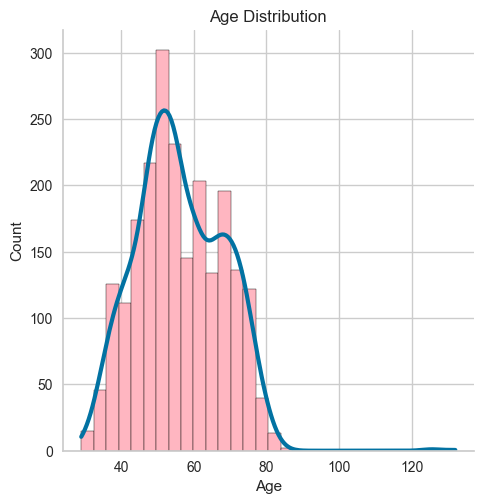

In [15]:
# plotting Histogram of count of Age of customers
'''
This code creates a histogram of the 'Age' column, dividing the data into 30 bins with light pink 
bars to show the frequency distribution. It overlays a smooth Kernel Density Estimate (KDE) 
line—styled with a black colour and a thickness (lw) of 3—to highlight the data's overall shape.
 Finally, it adds the title 'Age Distribution' to clearly label the chart for your analysis.
'''
sns.displot(df['Age'], kind = 'hist', facecolor = 'lightpink', bins = 30, kde = True, line_kws = {'color' : 'black', 'lw' : 3})
plt.title('Age Distribution')

Text(0.5, 1.0, 'Income Distribution')

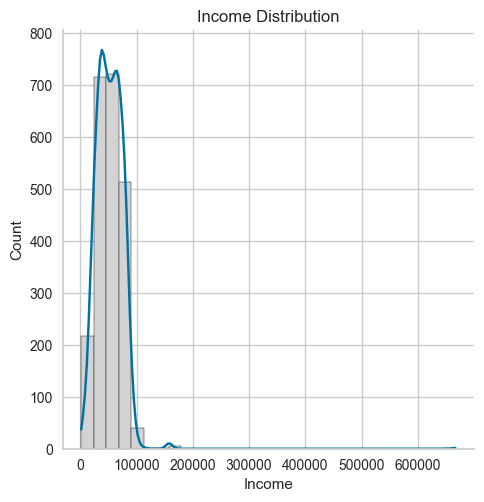

In [16]:
# Plotting Histogram fro income Distribution of customers 

sns.displot(df['Income'], kind = 'hist', kde = True, facecolor = 'lightgray', bins = 30)
plt.title('Income Distribution')

Text(0.5, 1.0, 'Spending Distribution')

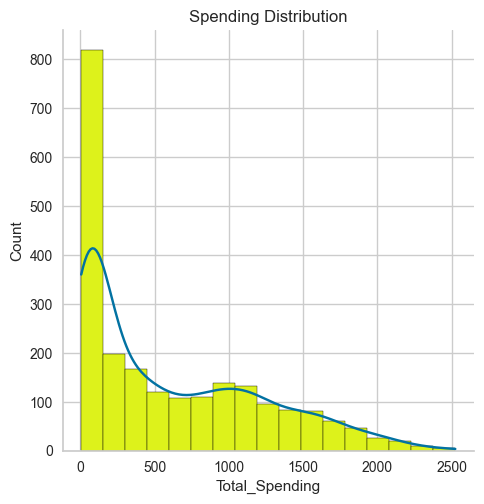

In [17]:
# Graph Of highest Spending Customers

sns.displot(df['Total_Spending'], kind = 'hist', kde = True, facecolor = '#ddf21b')
plt.title('Spending Distribution')

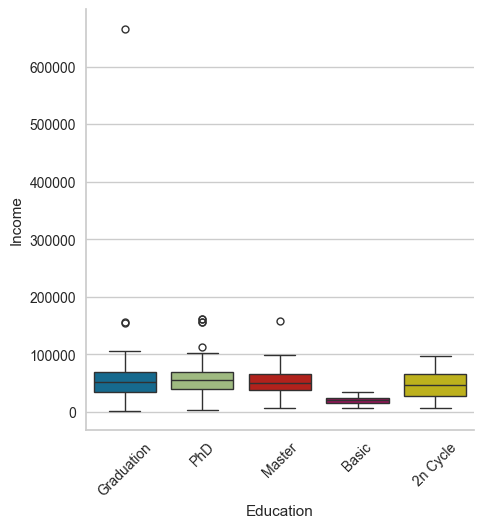

In [18]:
# Box Plotting of Education against Income of Customers
'''
This code generates a categorical box plot using kind='box' to compare the Income distribution 
across different Education levels, where hue='Education' assigns unique colours to each category 
for clear visual separation. By defining x and y axes from the df dataset, the plot highlights key 
statistical markers like the median, quartiles, and outliers. To ensure the chart is readable, 
plt.xticks(rotation=45) tilts the x-axis labels to prevent overlapping, and plt.show() renders 
the final visualization for analysis.
'''
sns.catplot(kind = 'box', data = df, x = 'Education', y = 'Income', hue= 'Education')
plt.xticks(rotation = 45)
plt.show()

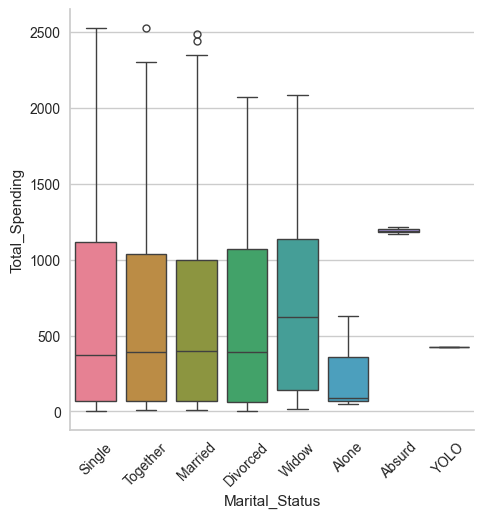

In [19]:
# Spending Based on Marital Status of Customers

sns.catplot(data = df, x = 'Marital_Status', y = 'Total_Spending', kind = 'box', hue = 'Marital_Status')
plt.xticks(rotation = 45)
plt.show()

In [20]:


corr = df[['Income', 'Age', 'Recency', 'Total_Spending', 'NumWebPurchases', 'NumStorePurchases']]
corr

,Income,Age,Recency,Total_Spending,NumWebPurchases,NumStorePurchases
0,58138.0,68,58,1617,8,4
1,46344.0,71,38,27,1,2
2,71613.0,60,26,776,8,10
3,26646.0,41,26,53,2,4
4,58293.0,44,94,422,5,6
...,...,...,...,...,...,...
2235,61223.0,58,46,1341,9,4
2236,64014.0,79,56,444,8,5
2237,56981.0,44,91,1241,2,13
2238,69245.0,69,8,843,6,10


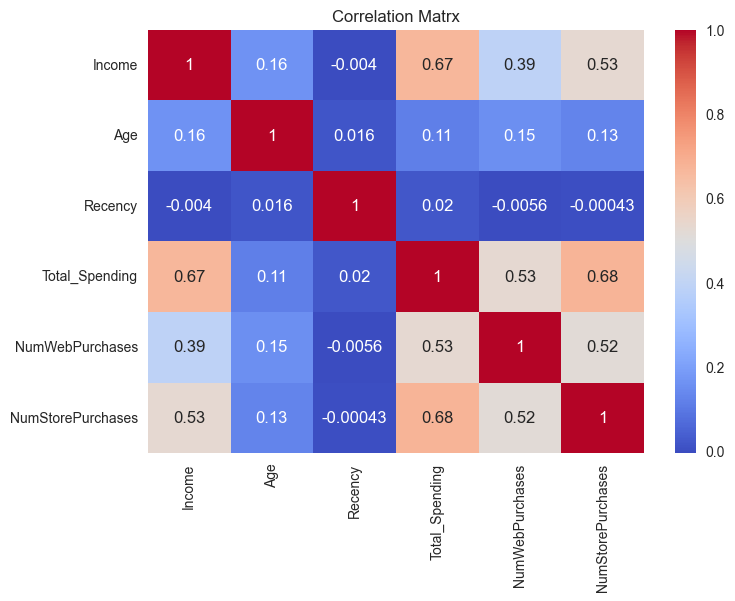

In [21]:
sns.heatmap(corr.corr(),annot = True, cmap = 'coolwarm')
plt.title('Correlation Matrx')
plt.show()

In [22]:
'''
This code creates a summary table (pivot_table) that calculates the average (mean) income for every 
combination of Education level and Marital_Status. It uses index='Education' to set the rows, 
columns='Marital_Status' to set the headers, and values='Income' to specify the data being measured,
effectively reshaping your raw dataset into a clean grid. The resulting pivot_income variable allows
you to quickly compare, for example, if "Married" individuals with a "PhD" earn more on average 
than those who are "Single."
'''
pivot_income = df.pivot_table(values = 'Income', index = 'Education', columns = 'Marital_Status', aggfunc = 'mean')
pivot_income

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,NaN,NaN,49395.130435,46201.100000,53673.944444,44736.410714,51392.200000,NaN
Basic,NaN,NaN,9548.000000,21960.500000,18238.666667,21240.071429,22123.000000,NaN
Graduation,79244.0,34176.0,54526.042017,50800.258741,51322.182927,55758.480702,54976.657143,NaN
Master,65487.0,61331.0,50331.945946,53286.028986,53530.560000,52109.009804,58401.545455,NaN
PhD,NaN,35860.0,53096.615385,58138.031579,53314.614583,56041.422414,60288.083333,48432.0


Text(0.5, 1.0, 'Average Income by Education')

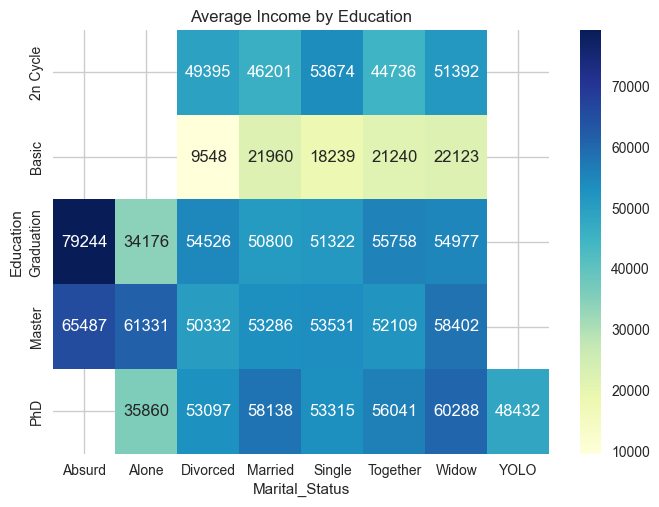

In [23]:
sns.heatmap(pivot_income, annot = True, fmt = '.0f', cmap = 'YlGnBu')
plt.title('Average Income by Education')

In [24]:
'''
This code calculates the average (mean) of Total_Spending for each Education category and then 
organizes the results in descending order (highest to lowest). It uses groupby('Education') to 
bundle the data by qualification, calculates the average spending per group, and applies 
sort_values(ascending=False) so you can immediately see which education level spends the most.
'''
group1 = df.groupby('Education')['Total_Spending'].mean().sort_values(ascending = False)

In [28]:
group1

Education
PhD           676.733888
Graduation    621.686380
Master        609.767123
2n Cycle      494.930000
Basic          81.796296
Name: Total_Spending, dtype: float64

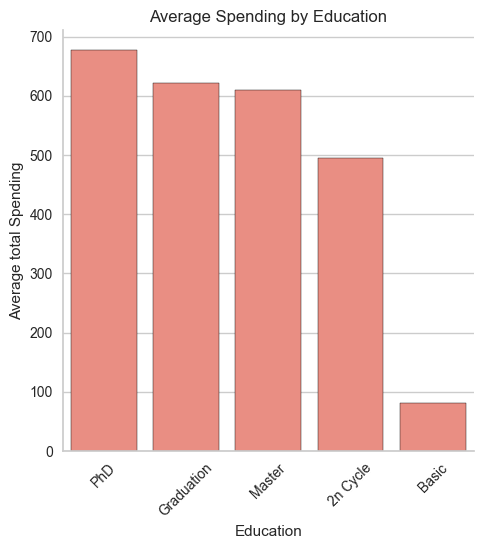

In [25]:
sns.catplot(group1, kind = 'bar', color = 'salmon', edgecolor = 'black')
plt.title('Average Spending by Education')
plt.ylabel('Average total Spending')
plt.xticks(rotation = 45)
plt.show()

In [26]:
'''
This code calculates the campaign acceptance rate for different Marital Status groups by first 
creating a binary 'AcceptedAny' column that marks a 1 if a customer accepted at least one of the 
six marketing campaigns (using .sum(axis=1) and a lambda function) and a 0 otherwise. It then uses
 groupby and .mean() to determine the percentage of customers in each status group who responded 
 positively, sorting the results in descending order. Finally, it visualizes these rates in an 
 orange bar chart with black edges, rotating the x-axis labels by 45 degrees and adding descriptive 
 titles and labels to compare which marital group is most responsive to marketing.

'''
df['AcceptedAny'] = df[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']].sum(axis = 1)

In [27]:
df['AcceptedAny'].unique()

array([1, 0, 3, 2, 4, 5])

In [28]:
df['AcceptedAny'] = df['AcceptedAny'].apply(lambda x : 1 if x > 0 else 0)

In [29]:
df['AcceptedAny'].unique()

array([1, 0])

In [30]:
group2 = df.groupby('Marital_Status')['AcceptedAny'].mean().sort_values(ascending = False)

In [35]:
group2

Marital_Status
Absurd      0.500000
YOLO        0.500000
Widow       0.342105
Alone       0.333333
Single      0.312102
Divorced    0.297414
Married     0.252042
Together    0.251309
Name: AcceptedAny, dtype: float64

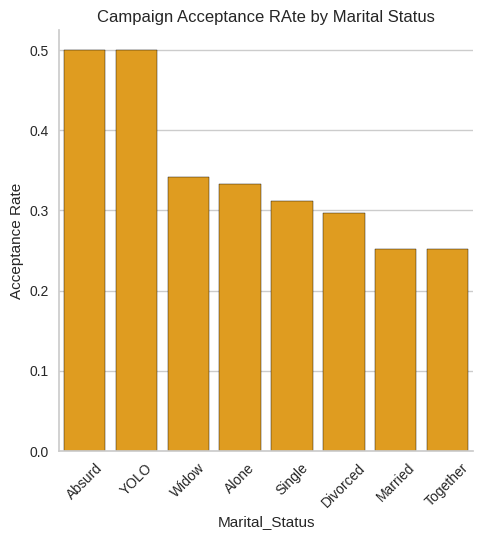

In [36]:
sns.catplot(group2, kind = 'bar', color = 'orange', edgecolor = 'black')
plt.title('Campaign Acceptance RAte by Marital Status')
plt.ylabel('Acceptance Rate')
plt.xticks(rotation = 45)
plt.show()

In [31]:
'''
This code performs data binning to categorize the continuous Age column into six distinct 
AgeGroup brackets based on the custom ranges defined in the bins list. It uses pd.cut() to assign 
each age to a specific text label (like '18-29' or '30-39'), effectively transforming individual ages
 into manageable groups for easier demographic analysis. The final .unique() or display of 
 df['AgeGroup'] allows you to verify that every customer has been successfully sorted into their 
 respective generational bucket.

'''
bins = [18, 30, 40, 50, 60, 70, 90]
labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70+']


df['AgeGroup'] = pd.cut(df['Age'], bins = bins, labels = labels)
df['AgeGroup']

0       60-69
1         70+
2       50-59
3       40-49
4       40-49
        ...  
2235    50-59
2236      70+
2237    40-49
2238    60-69
2239      70+
Name: AgeGroup, Length: 2216, dtype: category
Categories (6, str): ['18-29' < '30-39' < '40-49' < '50-59' < '60-69' < '70+']

In [32]:
group3 = df.groupby('AgeGroup')['Income'].mean()
group3

AgeGroup
18-29    46658.000000
30-39    46283.028302
40-49    49224.877034
50-59    50812.913303
60-69    56200.827887
70+      58944.316294
Name: Income, dtype: float64

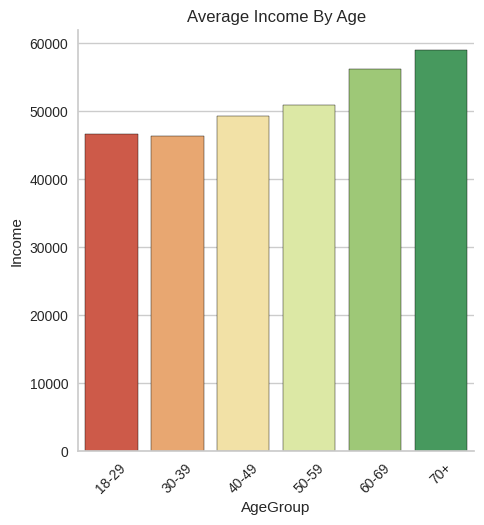

In [39]:
sns.catplot(group3, kind = 'bar', palette = 'RdYlGn', edgecolor = 'black')
plt.title('Average Income By Age')
plt.ylabel('Income')
plt.xticks(rotation = 45)
plt.show()

In [40]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spending,Customer_Since,AcceptedAny,AgeGroup
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,68,0,1617,4877,1,60-69
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,71,2,27,4327,0,70+
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,60,0,776,4526,0,50-59
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,41,1,53,4353,0,40-49
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,44,1,422,4375,0,40-49


In [41]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Total_Spending', 'Customer_Since',
       'AcceptedAny', 'AgeGroup'],
      dtype='object')

In [52]:
features = ['Age', 'Income', 'Total_Spending', 'NumWebPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Recency']

This code prepares your data and runs a diagnostic loop to find the optimal number of clusters for your K-Means model.
Feature Selection & Scaling: It selects specific numerical attributes like Age and Income, then uses StandardScaler to normalize them so that columns with larger numbers (like Income) don't unfairly dominate the clustering process.
The Diagnostic Loop: It iterates through a range of 2 to 15 clusters, training a new KMeans model for each step to see how well the data can be grouped.
Performance Metrics: During each loop, it calculates WCSS (Within-Cluster Sum of Squares) to measure how tight the clusters are and the Silhouette Score to measure how distinct the clusters are from each other.
Storage: It saves these values into lists so you can later plot them (the "Elbow Method" or "Silhouette Plot") to decide the perfect number of segments for your customers.

In [53]:
X = df[features].copy()

In [54]:
X

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
0,68,58138.0,1617,8,4,7,58
1,71,46344.0,27,1,2,5,38
2,60,71613.0,776,8,10,4,26
3,41,26646.0,53,2,4,6,26
4,44,58293.0,422,5,6,5,94
...,...,...,...,...,...,...,...
2235,58,61223.0,1341,9,4,5,46
2236,79,64014.0,444,8,5,7,56
2237,44,56981.0,1241,2,13,6,91
2238,69,69245.0,843,6,10,3,8


In [55]:
scaler = StandardScaler()


X_scaled = scaler.fit_transform(X)

In [56]:
wcss = []
Silhouette_score = []


for i in range(2, 16):
    kmeans = KMeans(n_clusters = i, random_state = 42)
    cluster_labels = kmeans.fit_predict(X_scaled)

    wcss.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, cluster_labels)

    Silhouette_score.append(sil_score)

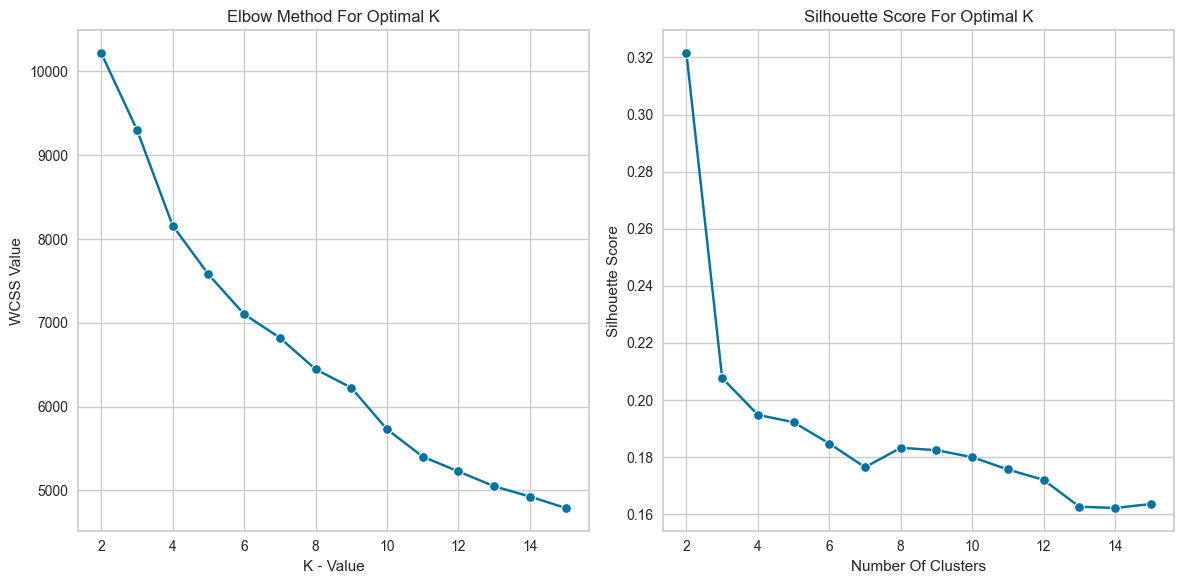

In [57]:
plt.figure(figsize = (12,6))
plt.subplot(121)
sns.lineplot(x = np.arange(2, 16), y = wcss, marker = 'o')
plt.title('Elbow Method For Optimal K')
plt.xlabel('K - Value')
plt.ylabel('WCSS Value')
plt.grid(True)

plt.subplot(122)
sns.lineplot(x = np.arange(2,16), y = Silhouette_score, marker = 'o')
plt.title('Silhouette Score For Optimal K')
plt.xlabel('Number Of Clusters')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.grid(True)
plt.show()

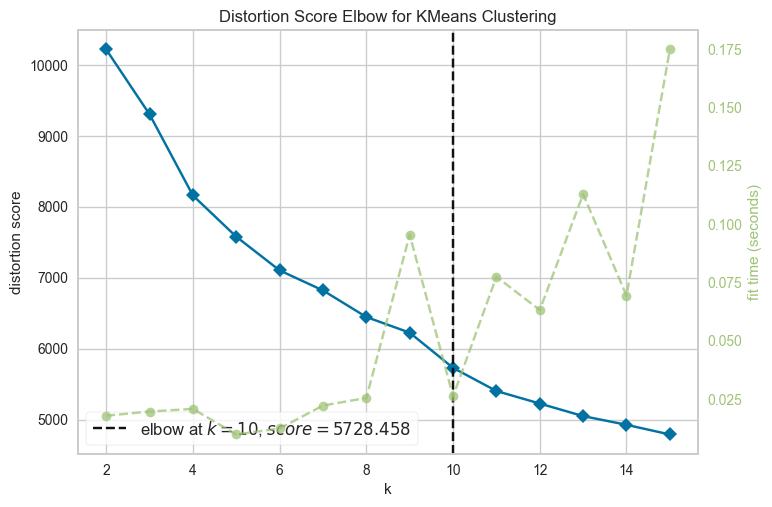

np.int64(10)

In [58]:
kmeans = KMeans(random_state = 42)
elbow = KElbowVisualizer(kmeans, k = (2, 16), force_model=True)
elbow.fit(X_scaled)
elbow.show(block = True)
elbow.elbow_value_

In [59]:
kmeans = KMeans(n_clusters = 6, random_state = 42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [61]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Response,Age,Total_Children,Total_Spending,Customer_Since,AcceptedAny,AgeGroup,Cluster,PCA1,PCA2
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,1,68,0,1617,4971,1,60-69,3,1.105180,1.630211
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,71,2,27,4421,0,70+,5,-1.334009,-0.209708
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,60,0,776,4620,0,50-59,3,1.888414,0.639592
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,41,1,53,4447,0,40-49,0,-1.778358,-0.717599
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,44,1,422,4469,0,40-49,2,0.008670,-0.383926


In [62]:
cluster_summary = df.groupby('Cluster')[features].mean()

In [63]:
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,48.758850,32837.701327,114.064159,2.157080,3.243363,6.652655,24.429204
1,46.089820,75444.853293,1307.272455,4.763473,8.799401,2.790419,48.685629
2,49.092643,32783.937330,116.757493,2.343324,3.196185,7.065395,77.005450
3,59.727907,59554.174419,884.241860,7.858140,7.925581,6.397674,46.097674
4,68.977778,77107.879365,1205.717460,4.536508,8.225397,2.526984,52.885714
5,68.028302,43426.745283,170.496855,2.575472,4.018868,5.371069,52.097484


In [64]:
df['Cluster'].value_counts()

Cluster
0    452
3    430
2    367
1    334
5    318
4    315
Name: count, dtype: int64

In [65]:
pca = PCA(n_components = 2)
pca_data = pca.fit_transform(X_scaled)
df['PCA1'], df['PCA2'] = pca_data[:, 0], pca_data[:, 1]


In [66]:
pca_data

array([[ 1.1075188 , -0.21175951],
       [-1.33673385,  0.269839  ],
       [ 1.88227676, -1.01416098],
       ...,
       [ 1.1535966 ,  1.15056999],
       [ 1.88768024, -1.16073698],
       [-0.84182091, -0.15963623]], shape=(2216, 2))

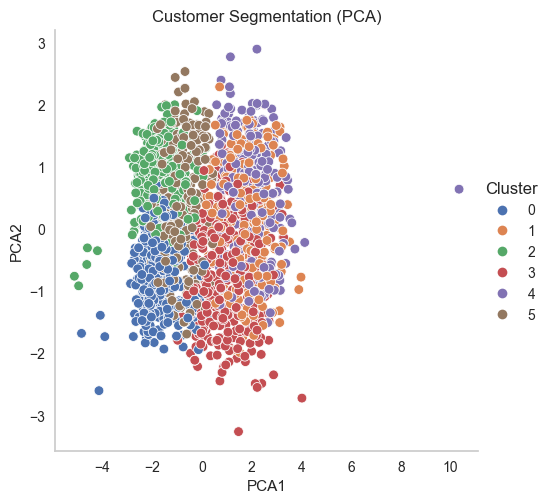

In [67]:
sns.relplot(data = df, x = 'PCA1', y = 'PCA2', hue = 'Cluster', palette = 'deep')
plt.title('Customer Segmentation (PCA)')
plt.grid(False)
plt.show()

In [68]:
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,48.758850,32837.701327,114.064159,2.157080,3.243363,6.652655,24.429204
1,46.089820,75444.853293,1307.272455,4.763473,8.799401,2.790419,48.685629
2,49.092643,32783.937330,116.757493,2.343324,3.196185,7.065395,77.005450
3,59.727907,59554.174419,884.241860,7.858140,7.925581,6.397674,46.097674
4,68.977778,77107.879365,1205.717460,4.536508,8.225397,2.526984,52.885714
5,68.028302,43426.745283,170.496855,2.575472,4.018868,5.371069,52.097484


# ****Conclusion :****

From above Analysis we can conclude that

- **`Cluster 0 :`** Low-income, low-spending customers who browse frequently online but convert rarely, making them highly price-sensitive and promotion-driven.

- **`Cluster 1 :`** Older, high-income, very high–value omnichannel customers with strong loyalty and consistent purchasing across web and store.

- **`Cluster 2 :`** Senior, moderate-income customers with low engagement and low spending, showing conservative and infrequent buying behavior.

- **`Cluster 3 :`** Upper-middle-income, digitally active customers with moderate to high spending and good potential for cross-sell and upsell.

- **`Cluster 4 :`** Younger affluent customers with the highest spending who prefer efficient, store-focused purchasing with minimal browsing.

- **`Cluster 5 :`** Wealthy senior customers with very high spending and high conversion rates, exhibiting focused, decisive buying and strong loyalty.

In [69]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']